In [10]:
!pip install torch_geometric -q
!pip install monty -q
!pip install pymatgen -q
!pip install matminer -q

In [11]:
import os, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.loader import DataLoader
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# --- paths (from your os.walk output) ---
NB04 = "/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project"

# --- reload graphs ---
graphs = torch.load(f"{NB04}/graphs.pt", weights_only=False)

# --- recreate the SAME grouped split ---
chemsys_to_idx = defaultdict(list)
for i, g in enumerate(graphs):
    chemsys_to_idx[g.chemsys].append(i)
unique_chemsys = np.array(list(chemsys_to_idx.keys()))
rng = np.random.default_rng(42)
shuffled = rng.permutation(unique_chemsys)
n = len(shuffled)
train_cs = set(shuffled[:int(0.8*n)])
val_cs   = set(shuffled[int(0.8*n):int(0.9*n)])
test_cs  = set(shuffled[int(0.9*n):])
train_graphs = [g for g in graphs if g.chemsys in train_cs]
val_graphs   = [g for g in graphs if g.chemsys in val_cs]
test_graphs  = [g for g in graphs if g.chemsys in test_cs]
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=64)
test_loader  = DataLoader(test_graphs, batch_size=64)
print(f"train {len(train_graphs)}  val {len(val_graphs)}  test {len(test_graphs)}")

# --- model ---
class GaussianRBF(nn.Module):
    def __init__(self, num_basis=50, cutoff=6.0):
        super().__init__()
        self.register_buffer("centers", torch.linspace(0, cutoff, num_basis))
        self.gamma = 1.0 / (cutoff / num_basis) ** 2
    def forward(self, d):
        return torch.exp(-self.gamma * (d - self.centers.unsqueeze(0)) ** 2)

class CGCNN(nn.Module):
    def __init__(self, hidden_dim=64, num_conv=3, num_rbf=50, cutoff=6.0, num_elements=100):
        super().__init__()
        self.atom_embedding = nn.Embedding(num_elements, hidden_dim)
        self.rbf = GaussianRBF(num_basis=num_rbf, cutoff=cutoff)
        self.convs = nn.ModuleList([CGConv(hidden_dim, dim=num_rbf, batch_norm=True)
                                    for _ in range(num_conv)])
        self.head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim),
                                  nn.SiLU(), nn.Linear(hidden_dim, 1))
    def forward(self, data):
        x = self.atom_embedding(data.x)
        e = self.rbf(data.edge_attr)
        for conv in self.convs:
            x = conv(x, data.edge_index, e)
        g = global_mean_pool(x, data.batch)
        return self.head(g).squeeze(-1)

# --- train / eval helpers ---
def train_epoch(model, loader, optimizer, device):
    model.train(); total, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = F.mse_loss(model(batch), batch.y)
        loss.backward(); optimizer.step()
        total += loss.item() * batch.num_graphs; n += batch.num_graphs
    return total / n

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval(); err, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        err += (model(batch) - batch.y).abs().sum().item(); n += batch.num_graphs
    return err / n

print("setup complete")

device: cuda
train 2026  val 167  test 441
setup complete


In [1]:
import os
for r, d, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(r, f))

/kaggle/input/datasets/ameeyabhusansahoo/materials-ml-cathode-data/li_electrodes_clean.parquet
/kaggle/input/datasets/ameeyabhusansahoo/materials-ml-cathode-data/host_structures.json
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/cgcnn_learning_curves.png
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/__results__.html
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/__notebook__.ipynb
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/graphs.pt
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/__output__.json
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/cgcnn_predicted_vs_actual.png
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/cgcnn_seed[0, 1, 2, 42, 7].pt
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/custom.css
/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project/__results___files/__results___16_0.png
/kaggle/input/notebooks/ameeyabhusansahoo/materials-

In [2]:
import torch
CKPT_DIR = "/kaggle/input/notebooks/ameeyabhusansahoo/materials-ml-project"
ckpt = torch.load(f"{CKPT_DIR}/cgcnn_seed[0, 1, 2, 42, 7].pt", map_location="cpu", weights_only=False)

print("type:", type(ckpt).__name__)
if isinstance(ckpt, dict):
    keys = list(ckpt.keys())
    print(f"number of keys: {len(keys)}")
    print(f"first few keys: {keys[:5]}")

type: OrderedDict
number of keys: 33
first few keys: ['atom_embedding.weight', 'rbf.centers', 'convs.0.lin_f.weight', 'convs.0.lin_f.bias', 'convs.0.lin_s.weight']


In [7]:
import torch
import torch.nn as nn
from torch_geometric.nn import CGConv, global_mean_pool

class GaussianRBF(nn.Module):
    def __init__(self, num_basis=50, cutoff=6.0):
        super().__init__()
        self.register_buffer("centers", torch.linspace(0, cutoff, num_basis))
        self.gamma = 1.0 / (cutoff / num_basis) ** 2
    def forward(self, d):
        return torch.exp(-self.gamma * (d - self.centers.unsqueeze(0)) ** 2)

class CGCNN(nn.Module):
    def __init__(self, hidden_dim=64, num_conv=3, num_rbf=50, cutoff=6.0, num_elements=100):
        super().__init__()
        self.atom_embedding = nn.Embedding(num_elements, hidden_dim)
        self.rbf = GaussianRBF(num_basis=num_rbf, cutoff=cutoff)
        self.convs = nn.ModuleList([CGConv(hidden_dim, dim=num_rbf, batch_norm=True)
                                    for _ in range(num_conv)])
        self.head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim),
                                  nn.SiLU(),
                                  nn.Linear(hidden_dim, 1))
    def forward(self, data):
        x = self.atom_embedding(data.x)
        e = self.rbf(data.edge_attr)
        for conv in self.convs:
            x = conv(x, data.edge_index, e)
        g = global_mean_pool(x, data.batch)
        return self.head(g).squeeze(-1)

In [8]:
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = F.mse_loss(pred, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        n += batch.num_graphs
    return total_loss / n

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    abs_err, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        abs_err += (pred - batch.y).abs().sum().item()
        n += batch.num_graphs
    return abs_err / n

In [12]:
import numpy as np

def run_and_save_one_seed(seed, max_epochs=200, patience=25):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = CGCNN().to(device)
    optimizer = Adam(model.parameters(), lr=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    best_val, best_state, bad = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        train_epoch(model, train_loader, optimizer, device)
        val_mae = evaluate(model, val_loader, device)
        scheduler.step(val_mae)
        if val_mae < best_val:
            best_val, best_state, bad = val_mae, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
        if bad >= patience:
            break

    # Save the BEST weights (not the final epoch) — important
    save_path = f"/kaggle/working/cgcnn_seed{seed}.pt"
    torch.save(best_state, save_path)

    model.load_state_dict(best_state)
    test_mae = evaluate(model, test_loader, device)
    return test_mae, best_val, save_path

SEEDS = [0, 1, 2, 42, 7]
for s in SEEDS:
    test_mae, best_val, path = run_and_save_one_seed(s)
    print(f"seed {s:3d}: best val {best_val:.3f}, test MAE {test_mae:.3f}, saved")

seed   0: best val 0.545, test MAE 0.499, saved
seed   1: best val 0.573, test MAE 0.507, saved
seed   2: best val 0.601, test MAE 0.519, saved
seed  42: best val 0.575, test MAE 0.483, saved
seed   7: best val 0.583, test MAE 0.505, saved


In [13]:
from sklearn.metrics import r2_score

SEEDS = [0, 1, 2, 42, 7]
models = []
for s in SEEDS:
    m = CGCNN().to(device)
    m.load_state_dict(torch.load(f"/kaggle/working/cgcnn_seed{s}.pt", map_location=device))
    m.eval()
    models.append(m)
print(f"Loaded {len(models)} ensemble members")

@torch.no_grad()
def ensemble_predict(models, loader, device):
    per_model, targets = [], None
    for m in models:
        preds, ys = [], []
        for batch in loader:
            batch = batch.to(device)
            preds.append(m(batch).cpu())
            ys.append(batch.y.cpu())
        per_model.append(torch.cat(preds).numpy())
        if targets is None:
            targets = torch.cat(ys).numpy()
    P = np.stack(per_model, axis=0)          # [n_models, n_samples]
    return P.mean(axis=0), P.std(axis=0), targets

mean_pred, std_pred, y_true = ensemble_predict(models, test_loader, device)

mae = np.abs(mean_pred - y_true).mean()
r2 = r2_score(y_true, mean_pred)
print(f"\nEnsemble MAE: {mae:.3f} V")
print(f"Ensemble R² : {r2:.3f}")
print(f"\nRaw uncertainty (std across 5 models):")
print(f"  mean   {std_pred.mean():.3f} V")
print(f"  median {np.median(std_pred):.3f} V")
print(f"  range  {std_pred.min():.3f} – {std_pred.max():.3f} V")

Loaded 5 ensemble members

Ensemble MAE: 0.462 V
Ensemble R² : 0.568

Raw uncertainty (std across 5 models):
  mean   0.202 V
  median 0.162 V
  range  0.018 – 0.950 V


In [14]:
abs_err = np.abs(mean_pred - y_true)
# split test set into low- vs high-uncertainty halves
median_std = np.median(std_pred)
low_u  = abs_err[std_pred <= median_std]
high_u = abs_err[std_pred >  median_std]
print(f"MAE on low-uncertainty half:  {low_u.mean():.3f} V")
print(f"MAE on high-uncertainty half: {high_u.mean():.3f} V")

from scipy.stats import spearmanr
rho, p = spearmanr(std_pred, abs_err)
print(f"Spearman corr (std vs |error|): {rho:.3f}  (p={p:.1e})")

MAE on low-uncertainty half:  0.467 V
MAE on high-uncertainty half: 0.456 V
Spearman corr (std vs |error|): 0.007  (p=8.8e-01)


In [15]:
dist_from_mean = np.abs(y_true - y_true.mean())
from scipy.stats import spearmanr
rho, p = spearmanr(std_pred, dist_from_mean)
print(f"Spearman(std, |voltage - mean_voltage|): {rho:.3f} (p={p:.1e})")
# negative rho => models AGREE (low std) on extreme voltages = the blind spot

Spearman(std, |voltage - mean_voltage|): 0.081 (p=8.8e-02)


In [16]:
alpha = 0.10                      # target 90% coverage

rng2 = np.random.default_rng(0)
idx = rng2.permutation(len(y_true))
half = len(idx) // 2
cal_idx, eval_idx = idx[:half], idx[half:]

# 1. residuals on the calibration half
cal_resid = np.abs(y_true[cal_idx] - mean_pred[cal_idx])

# 2. the conformal quantile (finite-sample corrected)
n_cal = len(cal_resid)
q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q = np.quantile(cal_resid, q_level)
print(f"90% prediction interval half-width: ±{q:.3f} V")

# 3. verify coverage on the untouched evaluation half
eval_resid = np.abs(y_true[eval_idx] - mean_pred[eval_idx])
coverage = np.mean(eval_resid <= q)
print(f"Empirical coverage on eval half: {coverage:.1%}  (target 90%)")

90% prediction interval half-width: ±0.899 V
Empirical coverage on eval half: 89.1%  (target 90%)


In [18]:
import numpy as np
import pandas as pd
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

# load + featurize (adjust path to your environment)
df = pd.read_parquet("/kaggle/input/datasets/ameeyabhusansahoo/materials-ml-cathode-data/li_electrodes_clean.parquet")
df = StrToComposition().featurize_dataframe(df, "framework_formula")
df = ElementProperty.from_preset("magpie").featurize_dataframe(df, "composition")

feat_cols = [c for c in df.columns if c.startswith("MagpieData")]
X = df[feat_cols].values
y = df["average_voltage"].values

# Fixed held-out test set (20%), never available for labeling
rng = np.random.default_rng(123)
perm = rng.permutation(len(X))
test_sz = int(0.2 * len(X))
test_idx = perm[:test_sz]
pool_idx = perm[test_sz:]          # the "unlabeled pool" we draw from
X_test, y_test = X[test_idx], y[test_idx]
print(f"test: {len(test_idx)}, pool: {len(pool_idx)}")

StrToComposition:   0%|          | 0/2634 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/2634 [00:00<?, ?it/s]

test: 526, pool: 2108


In [20]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
def bootstrap_uncertainty(X_train, y_train, X_query, n_models=5, seed=0):
    """Train a small bag of LightGBMs on bootstrap resamples;
    return per-point std across them as the uncertainty signal."""
    rng = np.random.default_rng(seed)
    preds = []
    for b in range(n_models):
        idx = rng.choice(len(X_train), len(X_train), replace=True)  # bootstrap
        m = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                          random_state=b, verbose=-1)
        m.fit(X_train[idx], y_train[idx])
        preds.append(m.predict(X_query))
    P = np.stack(preds)
    return P.mean(0), P.std(0)

def run_active_learning(strategy, pool_idx, seed,
                        n_seed=100, n_round=100, n_rounds=15):
    """One active-learning trajectory. strategy in {'random','uncertainty'}."""
    rng = np.random.default_rng(seed)
    pool = list(rng.permutation(pool_idx))
    labeled = pool[:n_seed]          # initial labeled seed set
    unlabeled = pool[n_seed:]
    curve = []

    for r in range(n_rounds):
        Xl, yl = X[labeled], y[labeled]
        mean_q, std_q = bootstrap_uncertainty(Xl, yl, X[unlabeled], seed=seed)

        # evaluate current model on the fixed test set
        mean_t, _ = bootstrap_uncertainty(Xl, yl, X_test, seed=seed)
        curve.append(mean_absolute_error(y_test, mean_t))

        if not unlabeled:
            break
        k = min(n_round, len(unlabeled))
        if strategy == 'random':
            pick = rng.choice(len(unlabeled), k, replace=False)
        else:  # uncertainty: take the highest-std unlabeled points
            pick = np.argsort(std_q)[-k:]
        pick = set(pick.tolist())
        labeled += [unlabeled[i] for i in pick]
        unlabeled = [u for i, u in enumerate(unlabeled) if i not in pick]

    return curve

# Repeat each strategy over several seeds for honest error bands
SEEDS = [0, 1, 2, 3, 4]
rand_curves, unc_curves = [], []
for s in SEEDS:
    rand_curves.append(run_active_learning('random', pool_idx, s))
    unc_curves.append(run_active_learning('uncertainty', pool_idx, s))
    print(f"seed {s} done")

rand = np.array(rand_curves)   # [n_seeds, n_rounds]
unc  = np.array(unc_curves)
labels_axis = 100 + 100 * np.arange(rand.shape[1])  # labeled set size each round
print("done")

seed 0 done
seed 1 done
seed 2 done
seed 3 done
seed 4 done
done


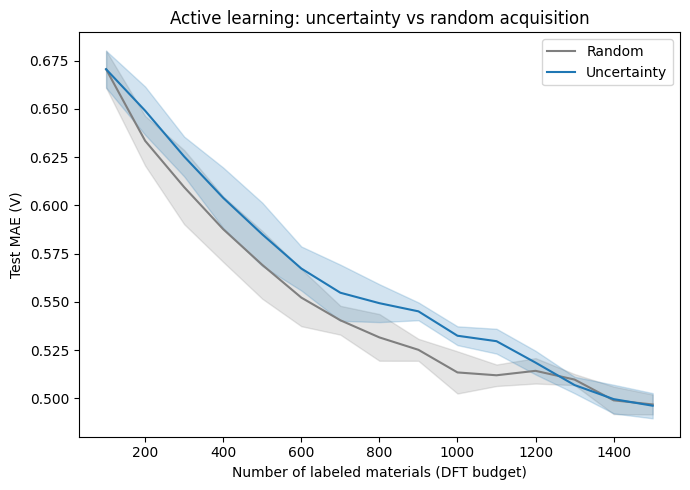

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for arr, name, c in [(rand, "Random", "tab:gray"), (unc, "Uncertainty", "tab:blue")]:
    m, sd = arr.mean(0), arr.std(0)
    ax.plot(labels_axis, m, label=name, color=c)
    ax.fill_between(labels_axis, m - sd, m + sd, alpha=0.2, color=c)
ax.set_xlabel("Number of labeled materials (DFT budget)")
ax.set_ylabel("Test MAE (V)")
ax.set_title("Active learning: uncertainty vs random acquisition")
ax.legend()
fig.tight_layout()
plt.savefig("active_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()